# 10 — Búsqueda de lugares, autores, enfermedades y medicamentos

Equivalente al notebook `12_busqueda_lugares_personajes.ipynb` de Karen,  
adaptado al dominio de salud.

**Busca por regex:**
- Departamentos de Colombia y ciudades principales
- Instituciones de salud colombianas e internacionales
- Autores / figuras clave en salud pública (equivalente a autores literarios de Karen)
- Enfermedades
- Medicamentos

**Entrada:** `corpus_cleaned.parquet`, `salud_tweets_final.parquet`, `salud_ner.parquet`  
**Salida:** parquet + Excel multi-hoja con todos los resultados


In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento')

print('[CONFIG] OK')


[CONFIG] OK


In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# ============================================================
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Corpus completo
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

# Subcorpus de comportamientos
tweets_comp  = pd.read_parquet(DATA_PROCESSED / 'comportamiento_tweets_final.parquet')

# Merge para obtener texto
df_comp  = tweets_comp.merge(
    corpus[['id_doc', 'Texto_limpio', 'Fecha', 'Author_Normalized', 'Entidad']],
    on='id_doc', how='left'
)
df_comp['Anio']  = df_comp['Fecha'].dt.year

print(f'Tweets de comp.: {len(df_comp):,}')
df_comp.head(2)


Tweets de comp.: 2,804


,chunk_id,id_doc,texto_chunk,Comp_Desinfectante,Comp_Distanciamiento,Comp_Etiqueta_tos_codo,Comp_Etiqueta_tos_panuelo,Comp_Evitar_reuniones,Comp_Lavado_manos,Comp_Mascarilla,score_max,subcat_max,etiqueta_comportamiento,categoria_detectada,Texto_limpio,Fecha,Author_Normalized,Entidad,Anio
0,17_1,17,A esas horas el covid19 se queda en la casa mi...,0.037909,0.313174,0.314862,0.321228,0.509031,0.192823,0.118177,0.509031,Comp_Evitar_reuniones,1,Comp_Evitar_reuniones,A esas horas el covid19 se queda en la casa mi...,2020-06-03,@elima2219,Sin descripción,2020
1,67_1,67,Los vendedores de balones de oxígeno y las pla...,0.253668,0.146621,0.448458,0.501524,0.200239,0.224089,0.342172,0.501524,Comp_Etiqueta_tos_panuelo,1,Comp_Etiqueta_tos_panuelo,Los vendedores de balones de oxígeno y las pla...,2020-06-03,@cmalcagmailcom1,Sin descripción,2020


In [3]:
# ============================================================
# CELL 2 — DICCIONARIOS DE TÉRMINOS
# (equivalente a los Excel externos de Karen)
# ============================================================

# --- Departamentos de Colombia ---
departamentos = {
    'Amazonas'          : ['Amazonas'],
    'Antioquia'         : ['Antioquia', 'Medellin', 'Medellín'],
    'Arauca'            : ['Arauca'],
    'Atlántico'         : ['Atlantico', 'Barranquilla'],
    'Bolívar'           : ['Bolivar', 'Cartagena'],
    'Boyacá'            : ['Boyaca', 'Tunja'],
    'Caldas'            : ['Caldas', 'Manizales'],
    'Caquetá'           : ['Caqueta', 'Florencia'],
    'Casanare'          : ['Casanare', 'Yopal'],
    'Cauca'             : ['Cauca', 'Popayan'],
    'Cesar'             : ['Cesar', 'Valledupar'],
    'Chocó'             : ['Choco', 'Quibdo'],
    'Córdoba'           : ['Cordoba', 'Monteria'],
    'Cundinamarca'      : ['Cundinamarca', 'Bogota', 'Bogotá'],
    'Guainía'           : ['Guainia'],
    'Guaviare'          : ['Guaviare'],
    'Huila'             : ['Huila', 'Neiva'],
    'La Guajira'        : ['Guajira', 'Riohacha'],
    'Magdalena'         : ['Magdalena', 'Santa Marta'],
    'Meta'              : ['Meta', 'Villavicencio'],
    'Nariño'            : ['Narino', 'Pasto'],
    'Norte de Santander': ['Norte de Santander', 'Cucuta', 'Cúcuta'],
    'Putumayo'          : ['Putumayo', 'Mocoa'],
    'Quindío'           : ['Quindio', 'Armenia'],
    'Risaralda'         : ['Risaralda', 'Pereira'],
    'San Andrés'        : ['San Andres'],
    'Santander'         : ['Santander', 'Bucaramanga'],
    'Sucre'             : ['Sucre', 'Sincelejo'],
    'Tolima'            : ['Tolima', 'Ibague', 'Ibagué'],
    'Valle del Cauca'   : ['Valle del Cauca', 'Cali'],
    'Vaupés'            : ['Vaupes', 'Mitu'],
    'Vichada'           : ['Vichada'],
}

# --- Instituciones de salud colombianas e internacionales ---
instituciones = {
    'Ministerio de Salud'        : ['Ministerio de Salud', 'MinSalud', 'Minsalud'],
    'INS'                        : ['INS', 'Instituto Nacional de Salud'],
    'INVIMA'                     : ['INVIMA', 'Invima'],
    'Secretaría de Salud'        : ['Secretaria de Salud', 'Secretaría de Salud', 'SecSalud'],
    'OMS/OPS'                    : ['OMS', 'OPS', 'PAHO', 'WHO'],
    'UNICEF'                     : ['UNICEF', 'Unicef'],
    'Cruz Roja'                  : ['Cruz Roja'],
    'EPS'                        : ['EPS'],
    'IPS'                        : ['IPS'],
    'ICBF'                       : ['ICBF'],
    'Médicos Sin Fronteras'      : ['Medicos Sin Fronteras', 'MSF'],
    'Sura'                       : ['Sura', 'EPS Sura'],
    'Colsanitas'                 : ['Colsanitas'],
    'Nueva EPS'                  : ['Nueva EPS'],
    'Coomeva'                    : ['Coomeva'],
    'Presidencia'                : ['Presidencia', 'Presidente'],
    'Hospital/Clínica'           : ['Hospital', 'Clínica', 'Clinica', 'UCI', 'UTI'],
    'SGSSS'                      : ['SGSSS', 'Sistema General de Seguridad Social'],
}

# --- Autores / figuras clave en comportamientos ---
# Equivalente a los autores literarios de Karen.
# Personas relevantes en el debate de comportamientos protectores
# durante la pandemia COVID-19 (marzo-agosto 2020).
# Fuente: investigacion sobre actores del sector salud en Colombia 2020.
#
# NOTA: Las EPS como instituciones ya estan en el diccionario 'instituciones'.
# Aqui van sus directivos y las figuras personales del debate publico.
autores_comp = {
    # ── Gobierno Nacional ──────────────────────────────────────────────────
    'Iván Duque'              : ['Ivan Duque', 'Iván Duque', 'Duque Márquez',
                                 'Duque Marquez'],
    'Fernando Ruiz'           : ['Fernando Ruiz', 'Ruiz Gomez', 'Ruiz Gómez',
                                 'Fernando Ruiz Gomez'],

    # ── INS ───────────────────────────────────────────────────────────────
    'Martha Ospina'           : ['Martha Ospina', 'Martha Lucia Ospina',
                                 'Martha Lucía Ospina', 'Ospina Martínez',
                                 'Ospina Martinez'],

    # ── Alcaldes (posesionados enero 2020) ────────────────────────────────
    'Claudia López'           : ['Claudia Lopez', 'Claudia López'],
    'Daniel Quintero'         : ['Daniel Quintero', 'Quintero Calle'],
    'Jorge Iván Ospina'       : ['Jorge Ivan Ospina', 'Jorge Ospina'],
    'Jaime Pumarejo'          : ['Jaime Pumarejo', 'Pumarejo'],
    'William Dau'             : ['William Dau', 'Dau'],

    # ── Gobernadores ──────────────────────────────────────────────────────
    'Aníbal Gaviria'          : ['Anibal Gaviria', 'Aníbal Gaviria',
                                 'Gaviria Correa'],      # Antioquia (se contagió)
    'Luis Fernando Suárez'    : ['Luis Fernando Suarez', 'Luis Fernando Suárez'],

    # ── Directivos EPS ────────────────────────────────────────────────────
    'José Fernando Cardona'   : ['Jose Fernando Cardona', 'Cardona'],  # Nueva EPS
    'Juan Gonzalo López'      : ['Juan Gonzalo Lopez', 'Juan Gonzalo López'],  # Salud Total / ACEMI
    'Sergio Martínez'         : ['Sergio Martinez', 'Sergio Martínez'],  # Sanitas / Keralty

    # ── Organismos internacionales ────────────────────────────────────────
    'Tedros Adhanom'          : ['Tedros', 'Tedros Adhanom', 'Director OMS'],

    # ── Expertos / voceros médicos ────────────────────────────────────────
    'Carlos Álvarez'          : ['Carlos Alvarez', 'Carlos Álvarez'],  # intensivista vocero COVID
    'Alejandro Gaviria'       : ['Alejandro Gaviria'],  # exministro, rector Uniandes
}

# --- Comportamientos protectores (encuesta ICARE) ---
comportamientos = {
    'Lavado_manos'         : ['lavado de manos', 'lavar manos', 'lavarse manos',
                               'lavate las manos', 'agua y jabon', 'higiene de manos'],
    'Desinfectante_manos'  : ['gel desinfectante', 'gel antibacterial', 'alcohol gel',
                               'desinfectante de manos', 'gel hidroalcoholico'],
    'Mascarilla'           : ['mascarilla', 'tapabocas', 'cubrebocas', 'KN95', 'N95',
                               'FFP2', 'barbijo', 'mascarilla quirurgica'],
    'Etiqueta_tos_codo'    : ['toser en el codo', 'estornudar en el codo',
                               'taparse al toser', 'etiqueta respiratoria', 'tos en el brazo'],
    'Etiqueta_tos_panuelo' : ['toser en panuelo', 'estornudar en panuelo',
                               'panuelo desechable', 'tirar panuelo'],
    'Distanciamiento'      : ['distanciamiento social', 'distancia social',
                               'guardar distancia', 'mantener distancia', 'dos metros',
                               'metro de distancia', 'distancia de seguridad', 'burbuja social'],
    'Evitar_reuniones'     : ['evitar reuniones', 'quedarse en casa', 'quedateencasa',
                               'confinamiento', 'cuarentena', 'aislamiento social',
                               'evitar aglomeraciones', 'cancelar eventos'],
}

# --- Barreras y facilitadores del comportamiento ---
barreras_facilitadores = {
    'Negacionismo'     : ['negacionismo', 'negacionista', 'bulo', 'bulos', 'fake news',
                           'conspiración', 'conspiracion', 'negacion covid'],
    'Miedo'            : ['miedo', 'temor', 'ansiedad', 'angustia', 'preocupacion',
                           'desesperanza', 'panico'],
    'Concienciacion'   : ['concienciacion', 'responsabilidad individual', 'autocuidado',
                           'prevenir contagio', 'proteger otros', 'solidaridad'],
    'Obediencia_normas': ['cumplir normas', 'respetar reglas', 'acatar medidas',
                           'seguir protocolos', 'medidas preventivas'],
    'Resistencia'      : ['resistencia', 'protesta', 'rechazo mascarilla',
                           'anti mascarilla', 'libertatd', 'no cuarentena'],
    'Fatiga_pandemia'  : ['fatiga pandemia', 'hartazgo', 'cansancio cuarentena',
                           'agotamiento pandemia', 'nueva normalidad'],
}

print(f'Departamentos  : {len(departamentos)}')
print(f'Instituciones  : {len(instituciones)}')
print(f'Autores comp.  : {len(autores_comp)}')
print(f'Comportamientos: {len(comportamientos)}')
print(f'Barreras/Facil : {len(barreras_facilitadores)}')


Departamentos  : 32
Instituciones  : 18
Autores comp.  : 16
Comportamientos: 7
Barreras/Facil : 6


In [4]:
# ============================================================
# CELL 3 — FUNCIÓN DE NORMALIZACIÓN Y BÚSQUEDA
# (Replica de Karen — misma lógica, adaptada a tweets)
# ============================================================

def normalizar_texto(texto: str) -> str:
    """Minúsculas, sin tildes, sin puntos."""
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    texto = texto.replace('.', '')
    return texto


def buscar_terminos(df_tweets: pd.DataFrame,
                    diccionario: dict,
                    col_salida: str) -> pd.DataFrame:
    """
    Busca términos (diccionario: {nombre_canonico: [variantes]})
    en el texto de los tweets.

    Retorna DataFrame con col_salida, id_doc, autor, fecha, variante hallada, texto.
    """
    textos_norm = df_tweets['Texto_limpio'].fillna('').map(normalizar_texto).to_numpy()
    id_docs     = df_tweets['id_doc'].to_numpy()
    autores     = df_tweets['Author_Normalized'].to_numpy()
    fechas      = df_tweets['Fecha'].to_numpy()
    subcats     = df_tweets['categoria_detectada'].to_numpy()
    textos_orig = df_tweets['Texto_limpio'].fillna('').to_numpy()

    resultados = []

    for nombre_canon, variantes in diccionario.items():
        variantes_norm = [normalizar_texto(v) for v in variantes if v.strip()]
        patron = re.compile(
            r'\b(' + '|'.join(re.escape(v) for v in variantes_norm) + r')\b'
        )

        for idx in range(len(textos_norm)):
            m = patron.search(textos_norm[idx])
            if m:
                resultados.append({
                    col_salida         : nombre_canon,
                    'Variante_hallada' : m.group(0),
                    'id_doc'           : id_docs[idx],
                    'autor'            : autores[idx],
                    'Fecha'            : fechas[idx],
                    'categoria_detectada': subcats[idx],
                    'Texto_limpio'     : textos_orig[idx],
                })

    df_res = pd.DataFrame(resultados)
    if not df_res.empty:
        df_res = (
            df_res
            .drop_duplicates(subset=[col_salida, 'id_doc'])
            .reset_index(drop=True)
        )
    return df_res


In [5]:
# ============================================================
# CELL 4 — BÚSQUEDA EN EL SUBCORPUS DE COMPORTAMIENTOS
# Equivalente a Karen: buscar lugares, personajes, autores, obras
# ============================================================

print('Buscando departamentos...')
df_res_depto = buscar_terminos(df_comp, departamentos, 'Departamento')
print(f'  Departamentos : {len(df_res_depto):,} menciones')

print('Buscando instituciones...')
df_res_inst  = buscar_terminos(df_comp, instituciones, 'Institucion')
print(f'  Instituciones : {len(df_res_inst):,} menciones')

print('Buscando autores / figuras clave...')
df_res_autores = buscar_terminos(df_comp, autores_comp, 'Autor_comp')
print(f'  Autores       : {len(df_res_autores):,} menciones')

print('Buscando comportamientos...')
df_res_comp  = buscar_terminos(df_comp, comportamientos, 'Comportamiento')
print(f'  Enfermedades  : {len(df_res_comp):,} menciones')

print('Buscando barreras y facilitadores...')
df_res_bar   = buscar_terminos(df_comp, barreras_facilitadores, 'Barrera_Facilitador')
print(f'  Medicamentos  : {len(df_res_bar):,} menciones')


Buscando departamentos...
  Departamentos : 202 menciones
Buscando instituciones...
  Instituciones : 168 menciones
Buscando autores / figuras clave...
  Autores       : 3 menciones
Buscando comportamientos...
  Enfermedades  : 981 menciones
Buscando barreras y facilitadores...
  Medicamentos  : 91 menciones


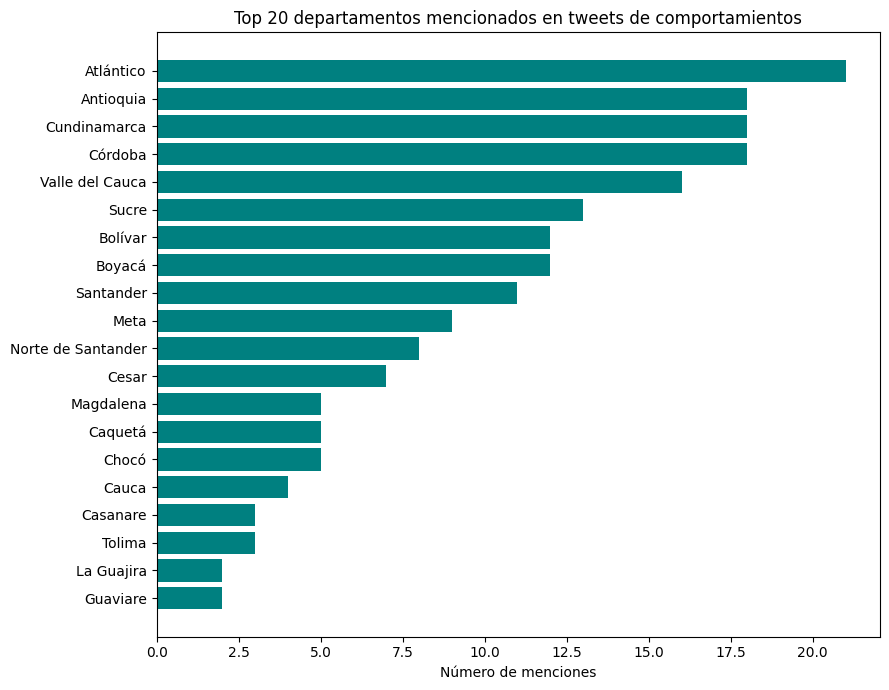

[GUARDADO] fig_top_departamentos_comp.png
      Departamento  Frecuencia
         Atlántico          21
         Antioquia          18
      Cundinamarca          18
           Córdoba          18
   Valle del Cauca          16
             Sucre          13
           Bolívar          12
            Boyacá          12
         Santander          11
              Meta           9
Norte de Santander           8
             Cesar           7
         Magdalena           5
           Caquetá           5
             Chocó           5
             Cauca           4
          Casanare           3
            Tolima           3
        La Guajira           2
          Guaviare           2


In [6]:
# ============================================================
# CELL 5 — TOP DEPARTAMENTOS
# ============================================================
freq_depto = (
    df_res_depto.groupby('Departamento').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_depto_top = freq_depto.head(20)
freq_depto_top_sorted = freq_depto_top.sort_values('Frecuencia', ascending=True)
ax.barh(freq_depto_top_sorted['Departamento'], freq_depto_top_sorted['Frecuencia'], color='teal')
ax.set_title('Top 20 departamentos mencionados en tweets de comportamientos')
ax.set_xlabel('Número de menciones')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_departamentos_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_departamentos_comp.png')
print(freq_depto.head(20).to_string(index=False))


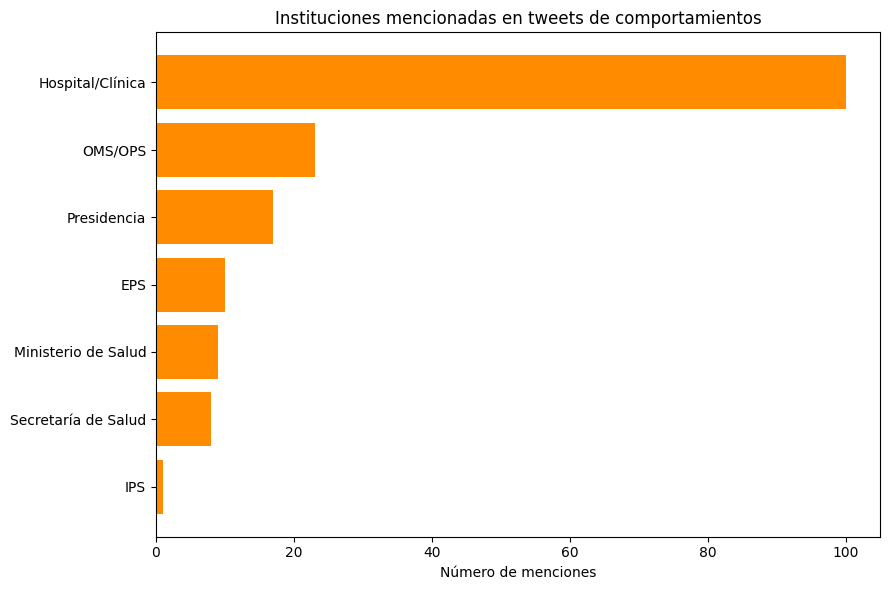

[GUARDADO] fig_top_instituciones_comp.png
        Institucion  Frecuencia
   Hospital/Clínica         100
            OMS/OPS          23
        Presidencia          17
                EPS          10
Ministerio de Salud           9
Secretaría de Salud           8
                IPS           1


In [7]:
# ============================================================
# CELL 6 — TOP INSTITUCIONES
# ============================================================
freq_inst = (
    df_res_inst.groupby('Institucion').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
freq_inst_s = freq_inst.sort_values('Frecuencia', ascending=True)
ax.barh(freq_inst_s['Institucion'], freq_inst_s['Frecuencia'], color='darkorange')
ax.set_title('Instituciones mencionadas en tweets de comportamientos')
ax.set_xlabel('Número de menciones')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_instituciones_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_instituciones_comp.png')
print(freq_inst.to_string(index=False))


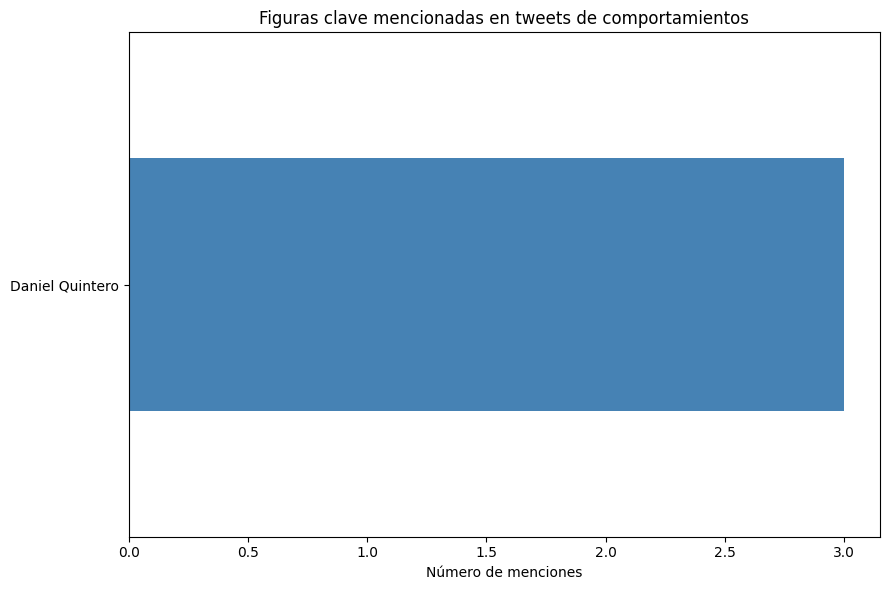

[GUARDADO] fig_top_autores_comportamiento_busqueda.png
     Autor_comp  Frecuencia
Daniel Quintero           3


In [8]:
# ============================================================
# CELL 5b — TOP AUTORES / FIGURAS CLAVE
# Equivalente a la búsqueda de autores literarios de Karen
# ============================================================

freq_autores = (
    df_res_autores.groupby('Autor_comp').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
freq_autores.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Autor_comp', y='Frecuencia', ax=ax, color='steelblue', legend=False
)
ax.set_title('Figuras clave mencionadas en tweets de comportamientos')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_autores_comportamiento_busqueda.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_autores_comportamiento_busqueda.png')
print(freq_autores.to_string(index=False))


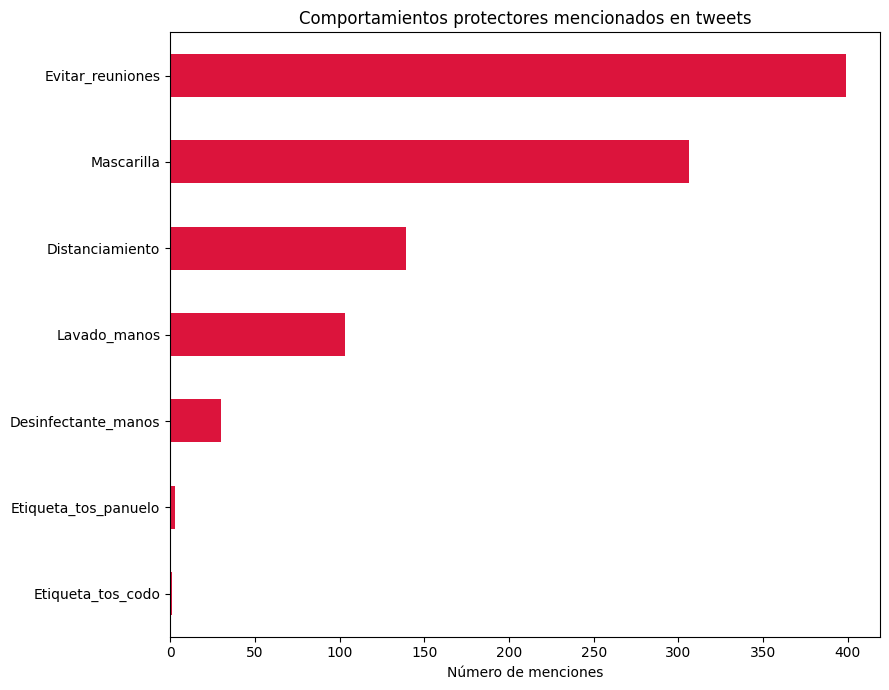

[GUARDADO] fig_top_comportamientos_comp.png
      Comportamiento  Frecuencia
    Evitar_reuniones         399
          Mascarilla         306
     Distanciamiento         139
        Lavado_manos         103
 Desinfectante_manos          30
Etiqueta_tos_panuelo           3
   Etiqueta_tos_codo           1


In [9]:
# ============================================================
# CELL 5c — TOP ENFERMEDADES
# ============================================================

freq_comp = (
    df_res_comp.groupby('Comportamiento').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_comp.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Comportamiento', y='Frecuencia', ax=ax, color='crimson', legend=False
)
ax.set_title('Comportamientos protectores mencionados en tweets')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_comportamientos_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_comportamientos_comp.png')
print(freq_comp.to_string(index=False))


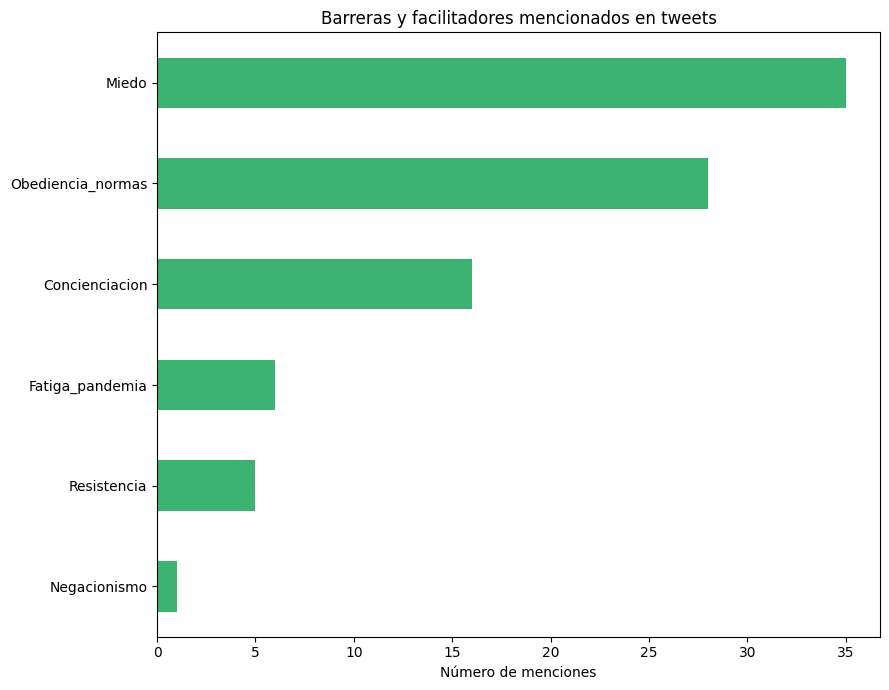

[GUARDADO] fig_top_barreras_comp.png
Barrera_Facilitador  Frecuencia
              Miedo          35
  Obediencia_normas          28
     Concienciacion          16
    Fatiga_pandemia           6
        Resistencia           5
       Negacionismo           1


In [10]:
# ============================================================
# CELL 5d — TOP MEDICAMENTOS
# ============================================================

freq_bar = (
    df_res_bar.groupby('Barrera_Facilitador').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_bar.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Barrera_Facilitador', y='Frecuencia', ax=ax, color='mediumseagreen', legend=False
)
ax.set_title('Barreras y facilitadores mencionados en tweets')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_barreras_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_barreras_comp.png')
print(freq_bar.to_string(index=False))


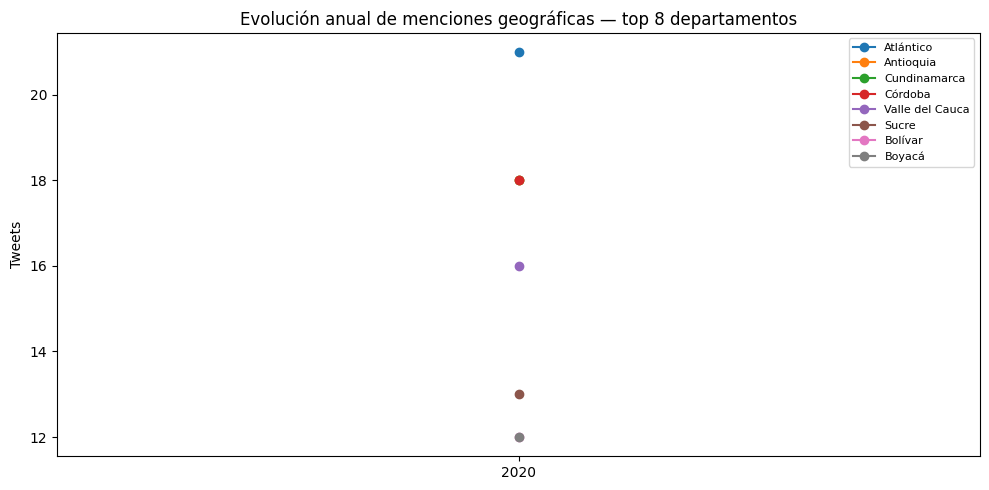

[GUARDADO] fig_evolucion_departamentos_comp.png


In [11]:
# ============================================================
# CELL 7 — EVOLUCIÓN TEMPORAL DE LUGARES E INSTITUCIONES
# ============================================================
df_res_depto['Anio'] = pd.to_datetime(df_res_depto['Fecha']).dt.year

evol_depto = (
    df_res_depto.groupby(['Anio', 'Departamento']).size()
    .reset_index(name='n')
)

# Top 8 departamentos para la visualización
top8_deptos = freq_depto.head(8)['Departamento'].tolist()
evol_depto_top = evol_depto[evol_depto['Departamento'].isin(top8_deptos)]

fig, ax = plt.subplots(figsize=(10, 5))
for depto in top8_deptos:
    sub = evol_depto_top[evol_depto_top['Departamento'] == depto]
    ax.plot(sub['Anio'].astype(str), sub['n'], marker='o', label=depto)

ax.set_title('Evolución anual de menciones geográficas — top 8 departamentos')
ax.set_ylabel('Tweets')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_evolucion_departamentos_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_evolucion_departamentos_comp.png')


In [12]:
# ============================================================
# CELL 8 — NER: ANÁLISIS DE ENTIDADES LOC DESDE comportamiento_ner
# (complementa la búsqueda por regex con las entidades ya extraídas)
# ============================================================
comportamiento_ner = pd.read_parquet(DATA_PROCESSED / 'comportamiento_ner.parquet')

# Aplanar entidades LOC
loc_rows = []
for _, row in comportamiento_ner.iterrows():
    for ent in row['entidades']:
        if len(ent) == 2 and ent[0] == 'LOC':
            loc_rows.append({
                'id_doc'   : row['id_doc'],
                'Anio'     : row['Anio'],
                'Entidad'  : str(ent[1]).strip(),
            })

df_loc_ner = pd.DataFrame(loc_rows)

freq_loc = (
    df_loc_ner.groupby('Entidad').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

print(f'Entidades LOC (NER) en subcorpus de comp.: {len(df_loc_ner):,} menciones')
print(f'Entidades únicas: {freq_loc["Entidad"].nunique():,}')
print()
print('Top 20 lugares (NER):')
print(freq_loc.head(20).to_string(index=False))


Entidades LOC (NER) en subcorpus de comp.: 1,077 menciones
Entidades únicas: 695

Top 20 lugares (NER):
            Entidad  Frecuencia
             Madrid          51
              China          31
       Barranquilla          15
Comunidad de Madrid          14
          Andalucía          14
           Colombia          14
               Cali          11
             México           8
           Matanzas           7
         California           7
            Caracas           7
             Boyacá           7
           Medellín           6
      San Francisco           6
            Soledad           6
             Bogotá           6
            Córdoba           6
          Cartagena           6
        Puerto Rico           5
           Trujillo           5


In [13]:
# ============================================================
# CELL 9 — GUARDAR TODOS LOS RESULTADOS
# ============================================================

# Asegurar tipos string para parquet
def limpiar_para_parquet(df, cols_str):
    for col in cols_str:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

df_res_depto   = limpiar_para_parquet(df_res_depto,   ['Departamento', 'Texto_limpio', 'Variante_hallada'])
df_res_inst    = limpiar_para_parquet(df_res_inst,    ['Institucion',  'Texto_limpio', 'Variante_hallada'])
df_res_autores = limpiar_para_parquet(df_res_autores, ['Autor_comp',  'Texto_limpio', 'Variante_hallada'])
df_res_comp     = limpiar_para_parquet(df_res_comp,     ['Comportamiento',   'Texto_limpio', 'Variante_hallada'])
df_res_bar     = limpiar_para_parquet(df_res_bar,     ['Barrera_Facilitador',  'Texto_limpio', 'Variante_hallada'])

df_res_depto.to_parquet(DATA_PROCESSED / 'resultados_departamentos_comportamiento.parquet', index=False)
df_res_inst.to_parquet(DATA_PROCESSED    / 'resultados_instituciones_comportamiento.parquet', index=False)
df_res_autores.to_parquet(DATA_PROCESSED / 'resultados_autores_comportamiento.parquet', index=False)
df_res_comp.to_parquet(DATA_PROCESSED    / 'resultados_comportamientos.parquet', index=False)
df_res_bar.to_parquet(DATA_PROCESSED    / 'resultados_barreras.parquet', index=False)

ruta_excel = DATA_PROCESSED / 'busqueda_terminos_comportamiento.xlsx'
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    freq_depto.to_excel(writer,   sheet_name='Departamentos',   index=False)
    freq_inst.to_excel(writer,    sheet_name='Instituciones',   index=False)
    freq_autores.to_excel(writer, sheet_name='Autores',         index=False)
    freq_comp.to_excel(writer,     sheet_name='Comportamientos',    index=False)
    freq_bar.to_excel(writer,     sheet_name='Barreras_Facilitadores',    index=False)
    freq_loc.head(100).to_excel(writer, sheet_name='LOC_NER',   index=False)
    df_res_depto.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_departamentos', index=False)
    df_res_inst.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_instituciones', index=False)
    df_res_autores.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_autores', index=False)
    df_res_comp.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_enfermedades', index=False)
    df_res_bar.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_medicamentos', index=False)

print('[GUARDADO] 5 archivos .parquet')
print(f'[GUARDADO] {ruta_excel.name}  ({ruta_excel})')
print()
print('Notebook 10 completado.')
print('Siguiente -> 11_descriptivos_avanzados_comportamiento.ipynb')


[GUARDADO] 5 archivos .parquet
[GUARDADO] busqueda_terminos_comportamiento.xlsx  (C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento\busqueda_terminos_comportamiento.xlsx)

Notebook 10 completado.
Siguiente -> 11_descriptivos_avanzados_comportamiento.ipynb
